# TechMind: clasificación de contenido técnico

## 1. Importación de librerías


In [1]:
import pandas as pd

ruta_dataset = "/content/dataset_final_actualizado_enriquecido.xlsx"
df = pd.read_excel(ruta_dataset)

print("Dimensiones originales:", df.shape)

filas_completamente_vacias = df.isna().all(axis=1).sum()
print("Filas completamente vacías:", filas_completamente_vacias)

df = df.dropna(how="all").copy()

print("Dimensiones después de la limpieza:", df.shape)

Dimensiones originales: (103, 13)
Filas completamente vacías: 5
Dimensiones después de la limpieza: (98, 13)


## 2. Carga y limpieza del dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 102
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    98 non-null     object
 1   titulo                98 non-null     object
 2   descripcion           98 non-null     object
 3   categoria             98 non-null     object
 4   subtema               98 non-null     object
 5   palabras_clave        98 non-null     object
 6   fuente                98 non-null     object
 7   url                   96 non-null     object
 8   tipo_fuente           98 non-null     object
 9   descripcion_adaptada  98 non-null     object
 10  fecha_recoleccion     98 non-null     object
 11  temas_relacionados    98 non-null     object
 12  resumen_corto         98 non-null     object
dtypes: object(13)
memory usage: 10.7+ KB


## 3. Validación de calidad de los datos

In [3]:
print("Duplicados por ID:", df["id"].duplicated().sum())
print("Duplicados por título:", df["titulo"].duplicated().sum())

print("\nValores nulos por columna:")
print(df.isnull().sum())

Duplicados por ID: 0
Duplicados por título: 0

Valores nulos por columna:
id                      0
titulo                  0
descripcion             0
categoria               0
subtema                 0
palabras_clave          0
fuente                  0
url                     2
tipo_fuente             0
descripcion_adaptada    0
fecha_recoleccion       0
temas_relacionados      0
resumen_corto           0
dtype: int64


### Registros con URL pendiente

In [4]:
filas_sin_url = df[df["url"].isna()]

print("Cantidad de registros sin URL:", len(filas_sin_url))

display(
    filas_sin_url[
        ["id", "titulo", "fuente", "url"]
    ]
)

Cantidad de registros sin URL: 2


,id,titulo,fuente,url
2,DS-003,Pandas: transformacion y manipulacion de datos,Alura - Pandas transformacion y manipulacion,NaN
69,CL-005,Redes y Protocolos: fundamentos de la web,Alura - Redes y Protocolos fundamentos de la web,NaN


## 4. Análisis exploratorio de datos

In [5]:
frecuencia = df["categoria"].value_counts()
porcentaje = df["categoria"].value_counts(normalize=True) * 100

tabla_frecuencias = pd.DataFrame({
    "Frecuencia": frecuencia,
    "Porcentaje": porcentaje.round(2)
})
tabla_frecuencias

,Frecuencia,Porcentaje
categoria,,
Data Science,20,20.41
Bases de Datos,20,20.41
Backend,20,20.41
Frontend,19,19.39
Cloud/DevOps,19,19.39


### Distribución de registros por categoría

In [6]:
tabla_distribucion_estilizada = (
    tabla_frecuencias.style
                     .format({"Porcentaje": "{:.1f}%"})
                     .bar(subset=["Frecuencia"], color="#B7A7E3")
                     .background_gradient(subset=["Porcentaje"], cmap="Purples")
                     .set_caption("Distribución de contenidos por categoría")
)
tabla_distribucion_estilizada

,Frecuencia,Porcentaje
categoria,,
Data Science,20,20.4%
Bases de Datos,20,20.4%
Backend,20,20.4%
Frontend,19,19.4%
Cloud/DevOps,19,19.4%


### Distribución visual de categorías


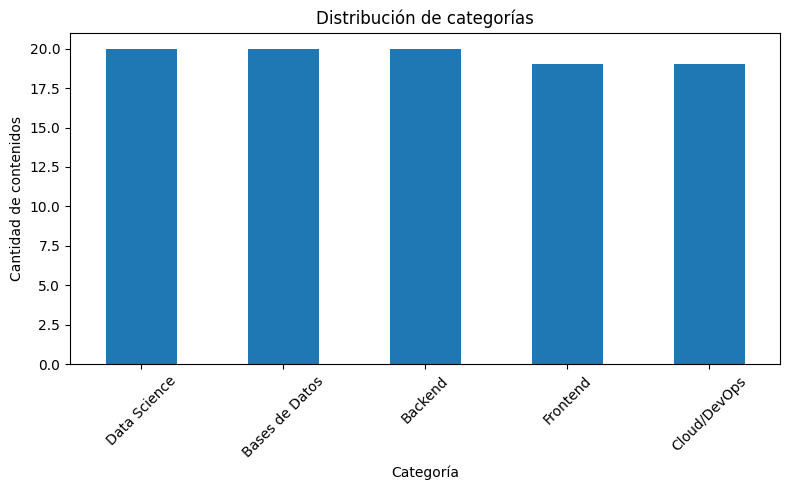

In [8]:
import matplotlib.pyplot as plt

conteo_categorias = df["categoria"].value_counts()

conteo_categorias.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de contenidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Preparación y limpieza del texto

In [9]:
import re

STOPWORDS_ES = {
    "el", "la", "los", "las", "de", "del", "en", "un", "una", "unos", "unas",
    "y", "o", "a", "para", "por", "con", "sin", "que", "como", "se", "su",
    "sus", "es", "son", "este", "esta", "estos", "estas", "al", "lo", "le",
    "les", "mas", "muy", "entre", "sobre", "ya", "desde", "cuando", "donde",
    "tambien", "antes", "despues", "usando", "uso"
}

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Záéíóúüñ\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ES and len(t) > 2]
    return " ".join(tokens)

In [10]:
df["texto_limpio"] = (
    df["titulo"].fillna("") + " " +
    df["descripcion_adaptada"].fillna("")
).apply(limpiar_texto)

df[["titulo", "texto_limpio"]]

,titulo,texto_limpio
0,Pandas: conociendo la biblioteca,pandas conociendo biblioteca importacion explo...
1,Pandas: seleccionar y agrupar datos,pandas seleccionar agrupar datos filtrado sele...
2,Pandas: transformacion y manipulacion de datos,pandas transformacion manipulacion datos creac...
3,Pandas E/S: trabajando con diferentes formatos...,pandas trabajando diferentes formatos archivo ...
4,NumPy: analisis numerico eficiente con Python,numpy analisis numerico eficiente python opera...
...,...,...
98,Buenas prácticas de programación: automatizand...,buenas prácticas programación automatizando pr...
99,Java y Tests: Test Driven Development con Junit,java tests test driven development junit aplic...
100,Java y refactorización: mejorando el código co...,java refactorización mejorando código buenas p...
101,Maven: gestione dependencias y haga Build de a...,maven gestione dependencias haga build aplicac...


In [11]:
df["longitud_texto"] = df["texto_limpio"].str.len()

df.groupby("categoria")["longitud_texto"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)

,count,mean,median,std,min,max
categoria,,,,,,
Backend,20,150.2,151.5,24.8,105,187
Bases de Datos,20,149.0,155.5,34.6,98,216
Cloud/DevOps,19,133.3,129.0,21.6,101,191
Data Science,20,131.7,124.5,27.6,100,181
Frontend,19,142.5,143.0,16.8,110,166


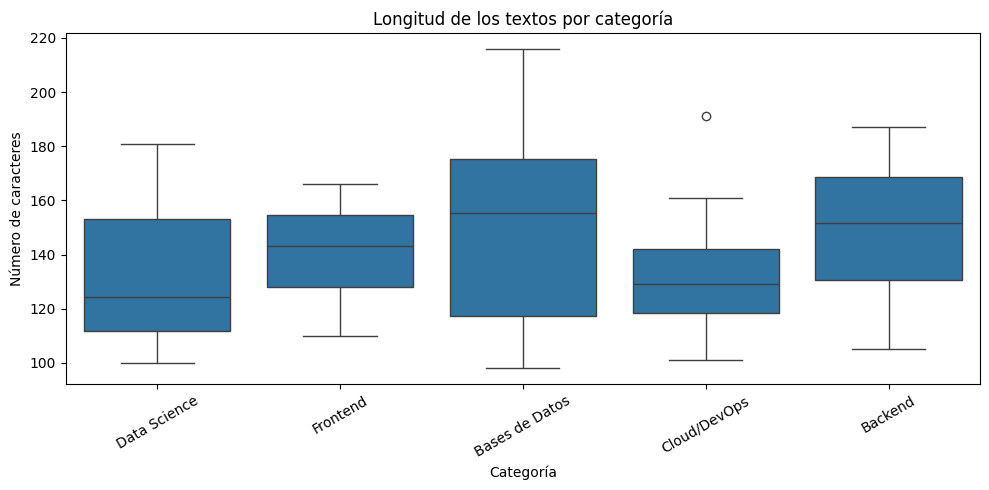

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="categoria", y="longitud_texto", ax=ax)
ax.set_title("Longitud de los textos por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de caracteres")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [24]:
df["texto_modelo"] = (
    df["titulo"].fillna("").astype(str) + " " +
    df["descripcion_adaptada"].fillna("").astype(str) + " " +
    df["palabras_clave"].fillna("").astype(str)
)

df["texto_modelo"] = (
    df["texto_modelo"]
    .str.replace(";", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Filas con texto vacío:", df["texto_modelo"].eq("").sum())

display(
    df[
        ["id", "categoria", "titulo", "texto_modelo"]
    ].head()
)

Filas con texto vacío: 0


,id,categoria,titulo,texto_modelo
0,DS-001,Data Science,Pandas: conociendo la biblioteca,Pandas: conociendo la biblioteca Importacion y...
1,DS-002,Data Science,Pandas: seleccionar y agrupar datos,Pandas: seleccionar y agrupar datos Filtrado s...
2,DS-003,Data Science,Pandas: transformacion y manipulacion de datos,Pandas: transformacion y manipulacion de datos...
3,DS-004,Data Science,Pandas E/S: trabajando con diferentes formatos...,Pandas E/S: trabajando con diferentes formatos...
4,DS-005,Data Science,NumPy: analisis numerico eficiente con Python,NumPy: analisis numerico eficiente con Python ...


## 6. División de datos de entrenamiento y prueba

In [25]:
from sklearn.model_selection import train_test_split

X = df["texto_modelo"]
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nDistribución en prueba:")
print(y_test.value_counts().sort_index())

Registros de entrenamiento: 78
Registros de prueba: 20

Distribución en entrenamiento:
categoria
Backend           16
Bases de Datos    16
Cloud/DevOps      15
Data Science      16
Frontend          15
Name: count, dtype: int64

Distribución en prueba:
categoria
Backend           4
Bases de Datos    4
Cloud/DevOps      4
Data Science      4
Frontend          4
Name: count, dtype: int64


## 7. Vectorización del texto con TF-IDF

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

print("Forma de entrenamiento:", X_train_tfidf.shape)
print("Forma de prueba:", X_test_tfidf.shape)
print("Cantidad de términos aprendidos:", len(vectorizador.get_feature_names_out()))


Forma de entrenamiento: (78, 2320)
Forma de prueba: (20, 2320)
Cantidad de términos aprendidos: 2320


## 8. Entrenamiento y comparación con el modelo baseline

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train_tfidf, y_train)
predicciones_modelo = modelo.predict(X_test_tfidf)

accuracy_modelo = accuracy_score(y_test, predicciones_modelo)
f1_modelo = f1_score(
    y_test,
    predicciones_modelo,
    average="macro"
)

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy.fit(X_train_tfidf, y_train)
predicciones_dummy = dummy.predict(X_test_tfidf)

accuracy_dummy = accuracy_score(y_test, predicciones_dummy)
f1_dummy = f1_score(
    y_test,
    predicciones_dummy,
    average="macro"
)

print("Modelo Logistic Regression")
print("Accuracy:", round(accuracy_modelo, 4))
print("F1 macro:", round(f1_modelo, 4))

print("\nDummyClassifier")
print("Accuracy:", round(accuracy_dummy, 4))
print("F1 macro:", round(f1_dummy, 4))

print("\nMejora en accuracy:")
print(round(accuracy_modelo - accuracy_dummy, 4))

Modelo Logistic Regression
Accuracy: 0.95
F1 macro: 0.9492

DummyClassifier
Accuracy: 0.2
F1 macro: 0.0667

Mejora en accuracy:
0.75


## 9. Validación cruzada del pipeline


In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

resultados = cross_validate(
    pipeline,
    df["texto_modelo"],
    df["categoria"],
    cv=cv,
    scoring=metricas
)

accuracy_media = resultados["test_accuracy"].mean()
accuracy_std = resultados["test_accuracy"].std()

f1_media = resultados["test_f1_macro"].mean()
f1_std = resultados["test_f1_macro"].std()

print("Accuracy por fold:")
print(resultados["test_accuracy"])

print("\nF1 macro por fold:")
print(resultados["test_f1_macro"])

print(f"\nAccuracy promedio: {accuracy_media:.4f}")
print(f"Desviación estándar accuracy: {accuracy_std:.4f}")

print(f"\nF1 macro promedio: {f1_media:.4f}")
print(f"Desviación estándar F1: {f1_std:.4f}")

Accuracy por fold:
[0.8        0.9        0.8        0.89473684 0.89473684]

F1 macro por fold:
[0.79920635 0.8984127  0.80761905 0.88698413 0.89920635]

Accuracy promedio: 0.8579
Desviación estándar accuracy: 0.0473

F1 macro promedio: 0.8583
Desviación estándar F1: 0.0451


In [32]:
dummy_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        DummyClassifier(
            strategy="most_frequent",
            random_state=42
        )
    )
])

resultados_dummy_cv = cross_validate(
    dummy_pipeline,
    df["texto_modelo"],
    df["categoria"],
    cv=cv,
    scoring="f1_macro"
)

## 10. Entrenamiento del pipeline final

In [33]:
modelo_final = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

modelo_final.fit(
    df["texto_modelo"],
    df["categoria"]
)

print("✅ Modelo final entrenado con", len(df), "registros.")
print("Categorías aprendidas:")
print(modelo_final.named_steps["modelo"].classes_)

✅ Modelo final entrenado con 98 registros.
Categorías aprendidas:
['Backend' 'Bases de Datos' 'Cloud/DevOps' 'Data Science' 'Frontend']


In [34]:
import joblib

ruta_modelo = "modelo_techmind_v2.joblib"

joblib.dump(modelo_final, ruta_modelo)

print("✅ Modelo guardado en:", ruta_modelo)

✅ Modelo guardado en: modelo_techmind_v2.joblib


In [35]:
import joblib

modelo_cargado = joblib.load("modelo_techmind_v2.joblib")

texto_prueba = [
    "Desarrollo de una API REST con Java y Spring Boot"
]

categoria_predicha = modelo_cargado.predict(texto_prueba)[0]
probabilidades = modelo_cargado.predict_proba(texto_prueba)[0]
probabilidad_maxima = probabilidades.max()

print("✅ Modelo cargado correctamente")
print("Categoría predicha:", categoria_predicha)
print("Probabilidad:", round(float(probabilidad_maxima), 4))

✅ Modelo cargado correctamente
Categoría predicha: Backend
Probabilidad: 0.4988


## 11. Resultados y métricas por categoría

In [19]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, preds, labels=labels, zero_division=0
)

metricas = pd.DataFrame({
    "categoria": labels, "precision": precision,
    "recall": recall, "f1": f1, "soporte": support
})

tabla_metricas = (
    metricas.style
            .format({"precision": "{:.1%}", "recall": "{:.1%}", "f1": "{:.1%}"})
            .hide(axis="index")
            .background_gradient(subset=["precision", "recall", "f1"], cmap="Purples")
            .highlight_min(subset=["precision", "recall", "f1"], color="#ffcccc")
            .set_caption("Métricas de clasificación por categoría")
)
tabla_metricas

categoria,precision,recall,f1,soporte
Backend,66.7%,100.0%,80.0%,6
Bases de Datos,83.3%,83.3%,83.3%,6
Cloud/DevOps,100.0%,83.3%,90.9%,6
Data Science,100.0%,83.3%,90.9%,6
Frontend,100.0%,83.3%,90.9%,6


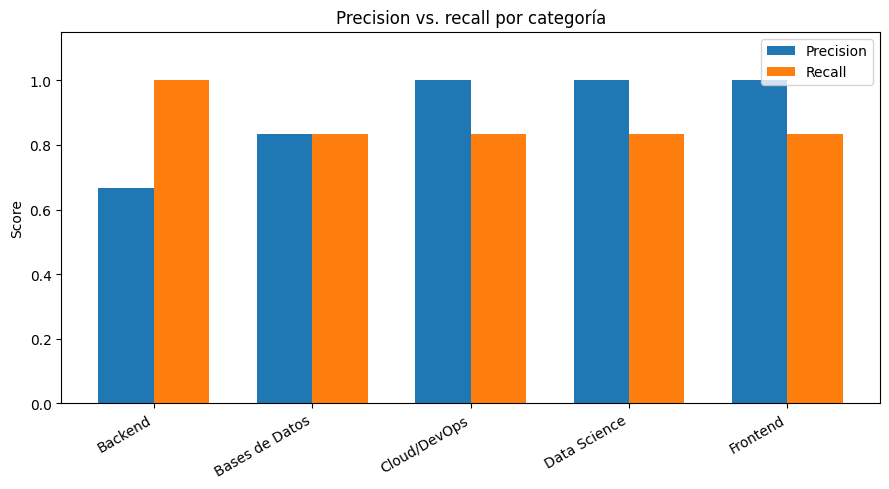

In [22]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

reporte = classification_report(
    y_test,
    preds,
    output_dict=True,
    zero_division=0
)

categorias = list(model.classes_)
precision = [reporte[categoria]["precision"] for categoria in categorias]
recall = [reporte[categoria]["recall"] for categoria in categorias]

x = np.arange(len(categorias))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - ancho / 2, precision, ancho, label="Precision")
ax.bar(x + ancho / 2, recall, ancho, label="Recall")

ax.set_ylabel("Score")
ax.set_title("Precision vs. recall por categoría")
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.show()

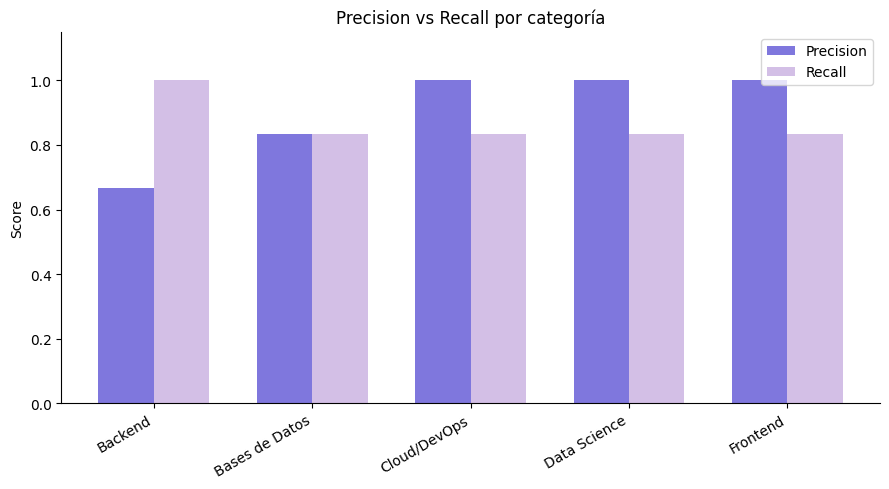

In [23]:
import numpy as np

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, precision, width, label='Precision', color='#7F77DD')
ax.bar(x + width/2, recall, width, label='Recall', color='#D3BFE6')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall por categoría')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Matriz de confusión y análisis de errores

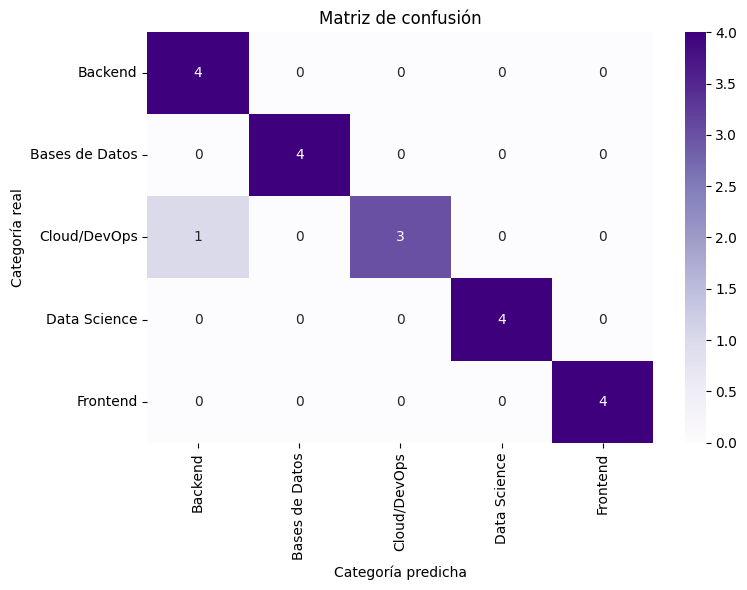

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
matriz = confusion_matrix(y_test, predicciones_modelo, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Matriz de confusión")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()

In [29]:
resultados_prueba = pd.DataFrame({
    "texto": X_test,
    "categoria_real": y_test,
    "categoria_predicha": predicciones_modelo
})

errores = resultados_prueba[
    resultados_prueba["categoria_real"] != resultados_prueba["categoria_predicha"]
].copy()

print("Cantidad de errores:", len(errores))
display(errores)

Cantidad de errores: 1


,texto,categoria_real,categoria_predicha
69,Redes y Protocolos: fundamentos de la web Fund...,Cloud/DevOps,Backend
